# Análisis de componentes principales (PCA)

El **análisis de componentes principales** (PCA, por sus siglas en inglés) es una técnica que nos ayuda a simplificar datos complejos. Imagina que tienes una tabla con muchas columnas (características) y quieres entenderla mejor o visualizarla. PCA toma esas muchas columnas y las combina en unas pocas nuevas columnas (llamadas "componentes principales") que capturan la mayor parte de la información original. Así, puedes ver patrones o agrupar datos más fácilmente, eliminando el "ruido" y quedándote con lo más importante. Es como resumir un libro largo en unas pocas frases clave.


El **Análisis de Componentes Principales (PCA)** es un algoritmo fundamental dentro de las técnicas de **aprendizaje no supervisado** (*unsupervised learning*) y un componente clave del preprocesamiento de datos en la Ciencia de Datos.

El objetivo primordial de PCA es la **reducción de dimensionalidad** (Dimensionality Reduction). Esto implica tomar un conjunto de datos con un gran número de variables (*features* o atributos) y encontrar una nueva representación que resuma sus características esenciales utilizando **un número significativamente menor de atributos**.

Esta técnica no elimina simplemente las columnas, sino que las transforma para crear un nuevo conjunto de **variables sintéticas, linealmente no correlacionadas**, conocidas como Componentes Principales (CPs).

### **II. Fundamento y Mecánica: La Perspectiva de Máxima Varianza**

PCA se deriva del principio de que, para retener la mayor cantidad de información posible durante la compresión, se debe **maximizar la varianza** en la representación de datos de baja dimensión.

#### 1. Pasos Operacionales Clave

1.  **Centrado y Estandarización de Datos:** Antes de aplicar PCA, es crucial preparar los datos. Esto generalmente implica **centrar los datos** (restando la media) y **escalarlos** (dividiendo por la desviación estándar) para que cada atributo tenga una media de cero y una varianza unitaria. Esto es vital, ya que si las características originales tienen diferentes órdenes de magnitud, aquellas con mayor rango dominarían injustamente el cálculo de la varianza.

2.  **Cálculo de la Matriz de Covarianza:** Se calcula la matriz de covarianza del conjunto de datos. Esta matriz simétrica describe cómo cada par de variables se relaciona (covaría) entre sí.

3.  **Descomposición de Autovalores y Autovectores:** El corazón de PCA es la **descomposición de autovalores** (eigenvalue decomposition) de la matriz de covarianza.
    *   Los **autovectores** (*eigenvectors*) resultantes definen las direcciones del nuevo subespacio dimensional y se convierten en los **Componentes Principales**.

    *   Los **autovalores** (*eigenvalues*) indican la **cantidad de varianza** que cada autovector (Componente Principal) retiene.

### Los Eigenvectors: Las "Direcciones" de los Datos
Un eigenvector es un vector que, al ser sometido a una transformación lineal, mantiene su dirección original; solo cambia su magnitud (se estira o se encoge).

• En PCA: Los eigenvectors de la matriz de covarianza representan las Componentes Principales (PC).

• Significado pedagógico: Imagina que tus datos forman una nube en forma de elipse o "huevo" en un gráfico. Los eigenvectors serían las líneas que atraviesan esa elipse a lo largo de sus ejes (el eje más largo y el eje más corto).

• Función: Definen el nuevo sistema de coordenadas. El primer eigenvector apunta en la dirección donde los datos tienen su máxima variación.

### Los Eigenvalues: La "Importancia" o el "Peso"
Un eigenvalue es el factor de escala (un número escalar) por el cual se multiplica el eigenvector durante la transformación.

• En PCA: Cada eigenvalue cuantifica la cantidad de varianza que captura el eigenvector correspondiente.
• Significado pedagógico: Si el eigenvector es la dirección del eje, el eigenvalue es la longitud o grosor de ese eje en la nube de datos.

• Función: Se utilizan para clasificar los componentes por importancia. El eigenvector con el eigenvalue más grande es el componente principal más informativo.

Comparación y Relación en el Algoritmo

Para que el proceso sea exitoso, PCA organiza estos elementos de la siguiente manera:
• Orden de relevancia: Los eigenvectors se ordenan según sus eigenvalues de mayor a menor.
• Reducción de dimensiones: Si queremos comprimir los datos, descartamos los eigenvectors que tienen eigenvalues pequeños, ya que esas direcciones contienen poco "ruido" o variabilidad irrelevante.
• Varianza total: La suma de todos los eigenvalues es igual a la varianza total de los datos originales (la traza de la matriz de covarianza).

#### 2. La Elección de los Componentes

El primer Componente Principal (PC1) es el autovector asociado al **autovalor más grande**, lo que significa que captura la **dirección de máxima varianza** en los datos.

Los CPs subsiguientes se seleccionan para ser **ortogonales** (perpendiculares y, por lo tanto, estadísticamente independientes) a los anteriores, maximizando la varianza restante. La dimensionalidad se reduce conservando solo los $M$ primeros Componentes Principales, que son los que acumulan la mayor parte de la varianza (por ejemplo, el 95% de la varianza total).

El Análisis de Componentes Principales (PCA) establece el número apropiado de componentes (reducción de dimensionalidad) basándose en la cantidad de **varianza** (o información) que cada nuevo componente retiene. La meta es reducir las dimensiones del espacio de características original manteniendo al mismo tiempo la mayor cantidad posible de información,.

El mecanismo central para determinar la importancia de cada nueva dimensión se basa en el **análisis de autovalores** (*eigenvalues*), que se obtienen de la matriz de covarianza de los datos.

#### Métodos para la Selección de Componentes Principales

PCA ordena las nuevas dimensiones de **"mejor a peor reteniendo información"**. Puesto que los autovalores indican la magnitud y se correlacionan con las direcciones más importantes, el primer componente principal (autovector) retiene la dirección de **máxima varianza** en los datos.

Existen tres métodos principales para determinar cuántos componentes seleccionar:

**1. Por Proporción de Varianza Explicada (Criterio de umbral)**

Este es el método más utilizado y consiste en calcular cuánta varianza acumula cada componente:

*   Se calcula la **proporción de variación explicada** por cada componente, que se ordena de mayor a menor.

*   La selección se detiene cuando la **suma acumulada** de estas proporciones alcanza un umbral mínimo preestablecido, como por ejemplo, el **85% o 95% de la variabilidad total**.

*   En herramientas como `scikit-learn`, el atributo `explained_variance_ratio_` proporciona esta matriz de proporciones en orden descendente para facilitar el cálculo.

**2. Por Método Gráfico (*Scree Plot*)**

El *scree plot* es una representación gráfica que ayuda a tomar una decisión visual, especialmente cuando la varianza explicada desciende rápidamente:

*   Se crea un gráfico especial (*scree plot*) que muestra la varianza explicada acumulada frente al número de componentes.

*   El criterio de selección es el **"método del codo"** (*chart elbow*), donde se identifica visualmente el punto en el gráfico en el que la tasa de descenso de la varianza explicada se **"afila"** o cae significativamente,. Los componentes retenidos son aquellos que se encuentran antes de este "codo".

**3. Por Elección Arbitraria o Contextual**

En situaciones donde la visualización es el objetivo principal, se puede elegir un número fijo bajo de componentes, típicamente **dos o tres**. Reducir la dimensionalidad a un espacio bajo (2D o 3D) facilita la visualización y el análisis de los datos.

### **III. Aplicación en Machine Learning**

PCA es una herramienta crítica en el flujo de trabajo de ML, especialmente en el **preprocesamiento** y la **exploración de datos**.

1.  **Visualización:** PCA se utiliza comúnmente para reducir conjuntos de datos de alta dimensión (como los 30 atributos del *Breast Cancer dataset* o las 784 dimensiones de imágenes $28\times28$) a solo dos o tres dimensiones. Esto permite **visualizar la estructura de los datos** y la separación de clases en un gráfico de dispersión, una tarea imposible en el espacio original de alta dimensión.

2.  **Compresión y Reducción de la Complejidad (*Feature Extraction*):** La compresión de datos mediante PCA reduce la necesidad de memoria y el **costo computacional** de entrenar modelos complejos. Al crear un subconjunto de características no correlacionadas, se **evita el sobreajuste** (*overfitting*) y se mitigan los problemas causados por la **maldición de la dimensionalidad** (*curse of dimensionality*).

3.  **Filtrado de Ruido (*Noise Filtering*):** La proyección de los datos en el subespacio principal a menudo retiene la señal subyacente mientras que la varianza restante, ignorada por la reducción, se asocia a menudo con el ruido.



### **IV. Ejemplo Completo en Python**

Ejemplo en Python utilizando la biblioteca `scikit-learn` para aplicar PCA a un conjunto de datos multidimensional. Este ejemplo simula la reducción de un espacio de 30 dimensiones a 2, tal como se realiza en el análisis del *Breast Cancer dataset* para fines de visualización.



Dimensiones originales del dataset (filas, columnas): (569, 30)

--- Vista del dataset original (Primeras 5 filas) ---


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



--- Estandarización y Aplicación de PCA ---
Dimensiones reducidas después de PCA: (569, 4)


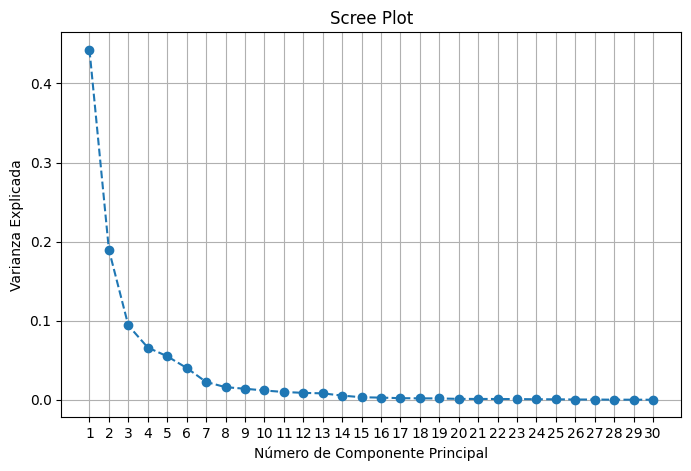


--- Análisis de Varianza Acumulada ---

 Componente  Varianza Explicada  Varianza Acumulada
          1            0.442720            0.442720
          2            0.189712            0.632432
          3            0.093932            0.726364
          4            0.066021            0.792385
          5            0.054958            0.847343
          6            0.040245            0.887588
          7            0.022507            0.910095

Umbral deseado: 80.00%
El número óptimo de componentes (m) para retener el 80.00% de la información es: 5
La dimensionalidad se redujo de 30 a 5 características.
La varianza retenida es: 0.8473

--- Componentes Principales Seleccionados ---
Componente 1: 0.4427
Componente 2: 0.1897
Componente 3: 0.0939
Componente 4: 0.0660
Componente 5: 0.0550

--- Fin del Análisis de Selección de Componentes ---

--- Vista de los datos reducidos (Primeras 5 filas) ---
        PC1        PC2       PC3       PC4       PC5     Target
0  9.192837   1.94858

,PC1,PC2,PC3,PC4,PC5,Target
0,9.192837,1.948583,-1.123166,-3.633731,1.195110,malignant
1,2.387802,-3.768172,-0.529293,-1.118264,-0.621775,malignant
2,5.733896,-1.075174,-0.551748,-0.912083,0.177086,malignant
3,7.122953,10.275589,-3.232790,-0.152547,2.960878,malignant
4,3.935302,-1.948072,1.389767,-2.940639,-0.546747,malignant


In [13]:

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Cargar el Dataset de Cáncer de Mama (30 features)
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# DESAFIO:
""" colocar X y y en base a un csv cargado desde local"""
# df = desde archivo csv local
# X = todos los atributos menos la columna target
# y = target


print(f"Dimensiones originales del dataset (filas, columnas): {X.shape}") 
#
# mostrar las primeras filas del dataset original
df_original = pd.DataFrame(data=X, columns=cancer.feature_names)
print("\n--- Vista del dataset original (Primeras 5 filas) ---")
display(df_original.head())

# 2. Estandarización de Datos (Paso Crucial de Preprocesamiento)

# PCA es sensible a la escala, por lo que se requiere la estandarización.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n--- Estandarización y Aplicación de PCA ---")

# 3. Aplicar PCA para reducir la dimensionalidad a 4 componentes

# El número de componentes (n_components) se ajusta al número deseado
# de dimensiones reducidas (e.g., 2 para visualización).
pca = PCA(n_components=4)

# Ajustar el modelo PCA a los datos escalados y transformarlos
X_pca = pca.fit_transform(X_scaled)

print(f"Dimensiones reducidas después de PCA: {X_pca.shape}") 
# El resultado debe ser (569, 2)

# 4. Análisis de la Varianza Explicada

# Se revisa cuánta información retienen los 2 componentes seleccionados.
# Ejecutar PCA para obtener todas las varianzas
# No especificamos n_components para obtener la varianza de todas las dimensiones
pca_completo = PCA() # calcule un optimo (cantidad de atributos)
pca_completo.fit(X_scaled)
varianza_explicada = pca_completo.explained_variance_ratio_

# generaun scre plot para visualizar la varianza explicada
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_explicada) + 1), varianza_explicada, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Varianza Explicada')
plt.xticks(range(1, len(varianza_explicada) + 1))
plt.grid()
plt.show()

#print(f"Varianza explicada por cada componente: {varianza_explicada}")
#print(f"Varianza acumulada total: {np.sum(varianza_explicada):.4f}")

# Aplicar el Criterio de Umbral

# Definimos el umbral deseado (e.g., retener el 95% de la varianza total)
umbral_deseado = 0.80 

# Calcular la suma acumulada de la varianza explicada [1, 4]
varianza_acumulada = np.cumsum(varianza_explicada)

# Encontrar el índice donde la varianza acumulada excede o iguala el umbral
# np.argmax devuelve el índice del primer valor Verdadero
m_optimo = np.argmax(varianza_acumulada >= umbral_deseado) + 1 
# Sumamos 1 porque los índices de Python comienzan en 0

print("\n--- Análisis de Varianza Acumulada ---\n")
# para didactica mostramos la tabla de varianza explicada y acumulada
# Mostrar la tabla de resultados (primeros m_optimo + 2 CPs), usa los nombres de componentes originales
df_varianza = pd.DataFrame({
    'Componente': range(1, len(varianza_explicada) + 1),
    'Varianza Explicada': varianza_explicada,
    'Varianza Acumulada': varianza_acumulada
})

print(df_varianza.head(m_optimo + 2).to_string(index=False))

# 4. Conclusión del Criterio de Umbral
print(f"\nUmbral deseado: {umbral_deseado * 100:.2f}%")
print(f"El número óptimo de componentes (m) para retener el {umbral_deseado * 100:.2f}% de la información es: {m_optimo}")

# 5. Reducción Final de Dimensionalidad
# Volvemos a aplicar PCA usando solo el número de componentes óptimo
pca_final = PCA(n_components=m_optimo)
X_reducido = pca_final.fit_transform(X_scaled)

# Corregir acceso a la forma de X: X.shape[1] es el número de características originales
print(f"La dimensionalidad se redujo de {X.shape[1]} a {m_optimo} características.")
print(f"La varianza retenida es: {varianza_acumulada[m_optimo-1]:.4f}")

# mostrar cuales son los componentes elegidos del dataset original
print("\n--- Componentes Principales Seleccionados ---")
for i, var in enumerate(varianza_explicada[:m_optimo]):
     print(f"Componente {i+1}: {var:.4f}")
print("\n--- Fin del Análisis de Selección de Componentes ---")

# 6. Visualización de los Componentes Seleccionados
# El nuevo dataset X_reducido contiene la proyección de los datos originales
# en el subespacio m-dimensional que maximiza la varianza.
df_reducido = pd.DataFrame(data=X_reducido, columns=[f'PC{i+1}' for i in range(m_optimo)])
df_reducido['Target'] = cancer.target_names[cancer.target]
print("\n--- Vista de los datos reducidos (Primeras 5 filas) ---")
print(df_reducido.head())
display(df_reducido.head())


# El dataset tiene 569 filas (muestras) y 30 columnas (features).

## Analisis PCA sobre iris

In [14]:
# Ensure nbformat is present so MIME-type rendering works in the notebook
# (installs into the current Jupyter environment)
# %pip install -q "nbformat>=4.2.0"

import plotly.express as px
import pandas as pd

df = pd.read_csv('../data/iris.csv')
features = df.columns[:-1]  # Todas las columnas excepto la última (especies)

fig = px.scatter(df, x='sepal_length', y='sepal_width', color='species',
                 title='Iris Dataset: Sepal Length vs Sepal Width', height=600, size_max=5)
fig.show()

In [15]:
fig = px.scatter_matrix(
    df,
    dimensions=features,
    color="species"
)
fig.update_traces(diagonal_visible=False)
# fijar leyenda en el top center
fig.update_layout(legend=dict(
    orientation="h",
    yanchor="bottom",
    y=1.02,
    xanchor="center",
    x=0.5
))

# fijar la altura del grafico
fig.update_layout(height=800)
fig.show()

In [16]:
#import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

features = df.columns[:-1]  # Todas las columnas excepto la última (especies)
# asegurar que las especies se traten como categóricas con un orden estable
species_cat = df['species'].astype('category')

pca = PCA(n_components=3)
components = pca.fit_transform(df[features])
total_var = pca.explained_variance_ratio_.sum() * 100

fig = px.scatter_3d(
    components,
    x=0,
    y=1,
    z=2,
    color=df['species'],
    title='Iris Dataset: 3D Scatter Plot of Sepal and Petal Dimensions',
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'},
    # cambiar tamaño del grafico
    height=700,
    # fijar tamaño de los puntos de los valores
    size_max=0.5
)
fig.show()